# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Daniel Andres Barona Sandoval, 2026

# 04_modelo
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
import os
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import joblib
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.3 MB/s eta 0:00:00


In [3]:
try:
    import pmdarima as pm
    from pmdarima.arima.utils import ndiffs, nsdiffs
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print('pmdarima no instalado: se usara grid search propio')

In [4]:
!git clone https://github.com/daniel-barona/proyecto_ciencia_datos

Cloning into 'proyecto_ciencia_datos'...
remote: Enumerating objects: 450, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 450 (delta 116), reused 82 (delta 82), pack-reused 320 (from 1)
Receiving objects: 100% (450/450), 608.04 MiB | 31.34 MiB/s, done.
Resolving deltas: 100% (260/260), done.
Updating files: 100% (56/56), done.


In [5]:
folder_path = Path("/content/proyecto_ciencia_datos/data/trusted")
files = list(folder_path.glob("*.xlsx"))
print(f"Archivos encontrados: {len(files)}")
for file in files:
    print(file.name)

Archivos encontrados: 1
SIPSA_2013_2026_trusted.xlsx


# DISEÑO DEL ALGORITMO

**La idea del algoritmo es la siguiente:**

1. El usuario debe seleccinar el departamento que desee estudiar, (puede escoger los departamentos disponibles, bogota esta incluido en la lista por el datset y Colombia tambien va a estar disponible si el usuario desea hacer un estudio a nivel nacional)
2. Despues de escoger el departamento (excluyendo bogota y colombia) el usuario podra escoger entre de las ciudades de ese departamento que pertenecen y que tienen activo centros de venta mayorista para poductos alimentarios.
3. Una vez escogido se le debe mostrar los productos disponibles en la ciudad.
4. el usuario escoge el producto a investigar.
5. Alli se empieza a realizar la estadistica, la idea es hacer selecion de todas las soliitudes realizadas por el usuario y realizar un problema de serie de tiempo
- Opcion A: usar los promedios mensuales por año (solicitud del cliente)
- Opcion B: recoletar todos los datos obtenidos de la solicitud de usuario por año
6. Debe realizar el analisis, presentar las graficas, presentar promedio de mes mensual actual (hasta junio) y dar la probabilidad del precio del producto en la cuidad seleccionada.


In [6]:
trusted_dir = "/content/proyecto_ciencia_datos/data/trusted"
df = pd.read_excel(f"{trusted_dir}/SIPSA_2013_2026_trusted.xlsx")
df

,fecha,grupo,producto,mercado,departamento,codigo_departamento,municipio,codigo_municipio,precio_promedio_kg,circulacion
0,2013-01-01,carnes,alas de pollo con costillar,"barranquilla, barranquillita",atlantico,8,barranquilla,8001,3073.0,si
1,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico guadalupe","bogota, d.c.",11,"bogota, d.c.",11001,2560.0,si
2,2013-01-01,carnes,alas de pollo con costillar,"cartagena, bazurto",bolivar,13,cartagena de indias,13001,3429.0,si
3,2013-01-01,carnes,alas de pollo con costillar,"ibague, plaza la 21",tolima,73,ibague,73001,4307.0,si
4,2013-01-01,carnes,alas de pollo con costillar,"medellin, plaza minorista ""jose maria villa""",antioquia,5,medellin,5001,3717.0,si
...,...,...,...,...,...,...,...,...,...,...
749048,2026-06-01,frutas,manzana royal gala importada,"neiva, surabastos",huila,41,neiva,41001,8706.0,si
749049,2026-06-01,frutas,manzana royal gala importada,"monteria, mercado del sur",cordoba,23,monteria,23001,8573.0,si
749050,2026-06-01,frutas,manzana royal gala importada,"medellin, central mayorista de antioquia",antioquia,5,medellin,5001,7517.0,si
749051,2026-06-01,frutas,naranja valencia,"valledupar, mercabastos",cesar,20,valledupar,20001,2494.0,si


## Entrenar el Modelo

In [7]:
departamentos_2026 = sorted(
    df.loc[df["fecha"].dt.year == 2026, "departamento"]
      .dropna()
      .unique()
)
departamentos_2026

['antioquia',
 'arauca',
 'atlantico',
 'bogota, d.c.',
 'bolivar',
 'boyaca',
 'caldas',
 'caqueta',
 'casanare',
 'cauca',
 'cesar',
 'cordoba',
 'cundinamarca',
 'huila',
 'magdalena',
 'meta',
 'narino',
 'norte de santander',
 'quindio',
 'risaralda',
 'santander',
 'sucre',
 'tolima',
 'valle del cauca']

In [8]:
departamentos = ['colombia'] + departamentos_2026

In [9]:
dropdown_departamento = widgets.Dropdown(
    options=departamentos,
    description='Departamento:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
display(dropdown_departamento)

Dropdown(description='Departamento:', layout=Layout(width='400px'), options=('colombia', 'antioquia', 'arauca'…

In [46]:
departamento = dropdown_departamento.value
print("Departamento seleccionado:", departamento)

Departamento seleccionado: colombia


In [47]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipios = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["municipio"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_municipio = widgets.Dropdown(
        options=municipios,
        description='Municipio:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    display(dropdown_municipio)

else:
    print("No es necesario seleccionar un municipio.")

No es necesario seleccionar un municipio.


In [48]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipio = dropdown_municipio.value
    print("Municipio seleccionado:", municipio)

In [50]:
if departamento.lower() == 'colombia':
    # Modo nacional: no se elige un mercado especifico, se promediara
    # el producto seleccionado en TODOS los mercados del pais.
    print("Modo nacional seleccionado: el producto se promediara entre todos los mercados del pais.")

elif departamento.lower() == 'bogota, d.c.':

    mercados = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_mercado = widgets.Dropdown(
        options=mercados,
        description='Mercado:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )
    display(dropdown_mercado)

else:

    municipio = dropdown_municipio.value

    mercados = sorted(
        df[
            (df["municipio"] == municipio) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_mercado = widgets.Dropdown(
        options=mercados,
        description='Mercado:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )
    display(dropdown_mercado)

Modo nacional seleccionado: el producto se promediara entre todos los mercados del pais.


In [53]:
if departamento.lower() == 'colombia':
    mercado = None
    print("Mercado: N/A (se calculará el promedio nacional)")
else:
    mercado = dropdown_mercado.value
    print("Mercado seleccionado:", mercado)

Mercado: N/A (se calculará el promedio nacional)


In [54]:
if mercado is None:
    # Nacional: productos disponibles en cualquier mercado del pais
    productos = sorted(
        df[df["fecha"].dt.year == 2026]["producto"]
        .dropna()
        .unique()
        .tolist()
    )
else:
    productos = sorted(
        df[
            (df["mercado"] == mercado) &
            (df["fecha"].dt.year == 2026)
        ]["producto"]
        .dropna()
        .unique()
        .tolist()
    )

dropdown_producto = widgets.Dropdown(
    options=productos,
    description='Producto:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
display(dropdown_producto)

Dropdown(description='Producto:', layout=Layout(width='400px'), options=('aceite de palma', 'aceite girasol', …

In [55]:
producto = dropdown_producto.value
print("Producto seleccionado:", producto)

Producto seleccionado: aguacate comun


## Inicio del Modelo - Hacer Pruebas

##Variables predefinidas

In [56]:
M = 12            # periodicidad estacional (12 = mensual con ciclo anual)
Use_LOG = True     # transformacion logaritmica para estabilizar varianza (exige precios > 0)
TEST_SIZE = None   # None = se calcula automaticamente; o forzar un numero de meses, ej. 12
H_FUTURO = 12       # meses a pronosticar hacia el futuro con el modelo ganador

# Fase 1: creacion de la serie

In [58]:
# Si mercado es None (modo nacional / departamento = 'colombia'), se  promedian los precios del producto entre TODOS los mercados del pais.
def preparar_serie(df, producto, mercado=None):
    base = df[df['producto'] == producto]
    if mercado is not None:
        base = base[base['mercado'] == mercado]

    serie = base[['fecha', 'precio_promedio_kg']].copy()
    serie = serie.sort_values('fecha')
    serie.set_index('fecha', inplace=True)
    serie.rename(columns={'precio_promedio_kg': 'precio'}, inplace=True)
    # Promedio de todos los registros de la misma fecha
    # (varios mercados/municipios reportando el mismo mes)
    serie = serie.groupby(serie.index).mean()
    # Frecuencia mensual + relleno de huecos
    serie = serie.asfreq('MS').interpolate('linear').ffill().bfill()
    return serie['precio']

y = preparar_serie(df, producto, mercado)
mercado_label = 'Colombia (promedio nacional)' if mercado is None else mercado
print(f'Serie construida ({mercado_label}): {len(y)} observaciones, '
      f'de {y.index[0].strftime("%Y-%m")} a {y.index[-1].strftime("%Y-%m")}')

display(y.round(2))


Serie construida (Colombia (promedio nacional)): 162 observaciones, de 2013-01 a 2026-06


,precio
fecha,
2013-01-01,2219.55
2013-02-01,2601.55
2013-03-01,2892.29
2013-04-01,2481.65
2013-05-01,1704.11
...,...
2026-02-01,7755.67
2026-03-01,7681.36
2026-04-01,7100.69


## Fase 1b — Verificación del tamaño de la serie
Antes de modelar, comprueba que la serie tenga suficientes observaciones. Reglas prácticas para SARIMA con estacionalidad mensual (m=12):

- **< 24 meses**: insuficiente — no se puede estimar componente estacional.
- **24–35 meses**: mínimo aceptable — modelo poco confiable, evita SARIMA (usa ARIMA no estacional).
- **36–47 meses**: aceptable — SARIMA viable pero con incertidumbre alta.
- **48–71 meses**: bueno — recomendado (≥ 4 ciclos estacionales).
- **≥ 72 meses**: óptimo (≥ 6 ciclos).

In [59]:
def fuerza_estacional(y, m=12):
    """Fs = max(0, 1 - Var(resid)/Var(resid+seasonal))  (Hyndman). >0.3 ~ estacionalidad util."""
    if len(y) < 2*m + 1:
        return np.nan
    try:
        res = STL(y, period=m, robust=True).fit()
    except Exception:
        return np.nan
    var_r  = np.nanvar(res.resid)
    var_rs = np.nanvar(res.resid + res.seasonal)
    return float(max(0.0, 1 - var_r/var_rs)) if var_rs > 0 else 0.0

def verificar_registros(y, m=12):
    n = int(y.dropna().shape[0])
    ciclos = n / m
    nivel = ('INSUFICIENTE' if n < 24 else 'MINIMO' if n < 36 else
             'ACEPTABLE' if n < 48 else 'BUENO' if n < 72 else 'OPTIMO')

    Fs = fuerza_estacional(y, m)
    ciclos_ok = n >= 3*m
    # FIX: la estacionalidad se usa solo si hay ciclos suficientes Y senal estacional real
    seasonal_ok = bool(ciclos_ok and np.isfinite(Fs) and Fs >= 0.30)
    seasonal_debil = bool(ciclos_ok and np.isfinite(Fs) and 0.15 <= Fs < 0.30)

    # presupuesto de parametros: ~1 por cada 10 observaciones
    presupuesto = max(2, n // 10)
    max_p = 3 if n >= 60 else 2 if n >= 36 else 1
    max_q = max_p
    max_P = 1 if seasonal_ok else 0
    max_Q = 1 if (seasonal_ok and n >= 4*m) else 0

    # horizonte de backtest: al menos 1 ciclo si alcanza, dejando train >= 3 ciclos
    h_bt = int(min(m, max(6, n // 5), max(3, n - max(3*m, 24))))

    info = dict(n=n, ciclos=round(ciclos,2), nivel=nivel, apto=n>=24, m=m,
                Fs=None if not np.isfinite(Fs) else round(Fs,3),
                seasonal_ok=seasonal_ok, seasonal_debil=seasonal_debil,
                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                presupuesto=presupuesto, h_bt=h_bt)

    print(f"Registros            : {n}")
    print(f"Ciclos (m={m})        : {ciclos:.2f}")
    print(f"Nivel                : {nivel}")
    print(f"Fuerza estacional Fs : {info['Fs']}  (>=0.30 usa SARIMA, <0.15 no aporta)")
    print(f"Componente estacional: {'SI' if seasonal_ok else 'NO -> ARIMA no estacional'}"
          + (' [debil]' if seasonal_debil else ''))
    print(f"Limites busqueda     : p<={max_p} q<={max_q} P<={max_P} Q<={max_Q} (max {presupuesto} params)")
    print(f"Horizonte backtest   : {h_bt} meses")
    if not info['apto']:
        print('ATENCION: serie insuficiente para modelar (<24).')
    return info
info = verificar_registros(y)


Registros            : 162
Ciclos (m=12)        : 13.50
Nivel                : OPTIMO
Fuerza estacional Fs : 0.687  (>=0.30 usa SARIMA, <0.15 no aporta)
Componente estacional: SI
Limites busqueda     : p<=3 q<=3 P<=1 Q<=1 (max 16 params)
Horizonte backtest   : 12 meses


#Fase 3: EDA express y especifico

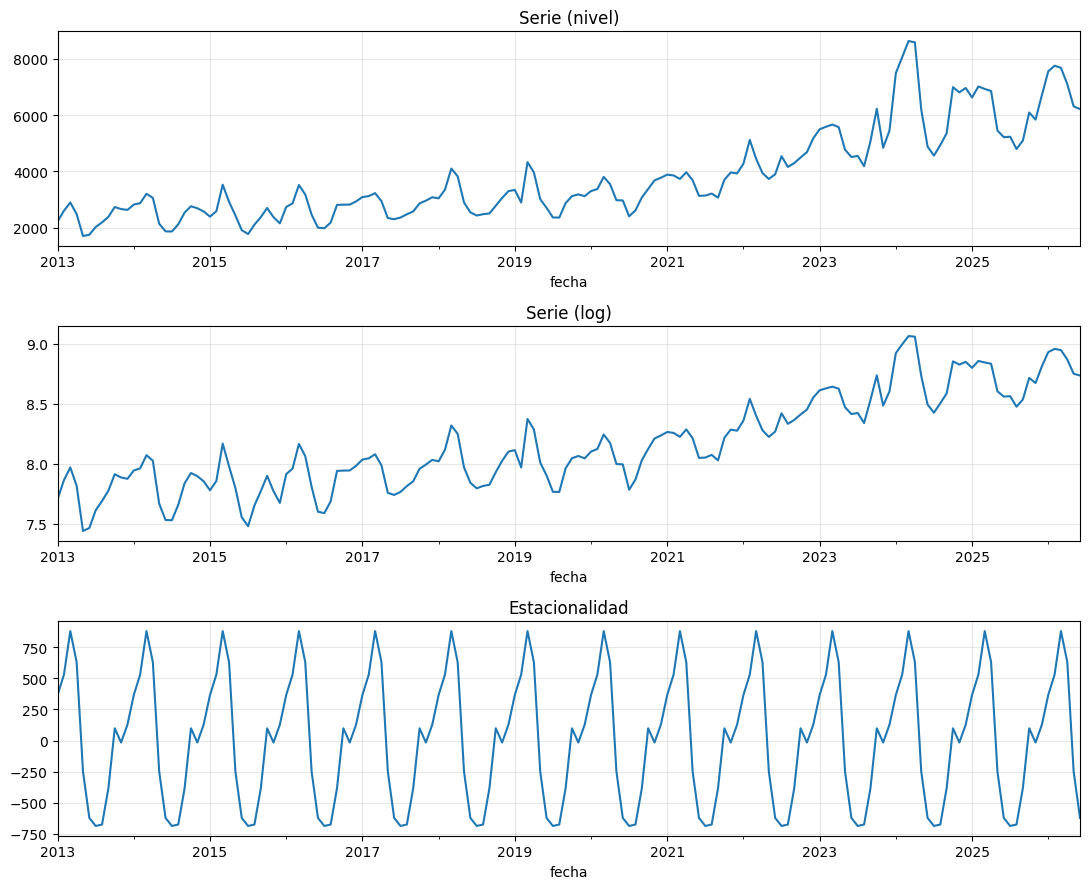

Amplitud estacional = 1,564.9 (41.0% del nivel medio)


In [60]:
fig, ax = plt.subplots(3,1, figsize=(11,9))
y.plot(ax=ax[0], title='Serie (nivel)'); ax[0].grid(alpha=.3)
np.log(y).plot(ax=ax[1], title='Serie (log)'); ax[1].grid(alpha=.3)
if len(y) >= 2*M:
    seasonal_decompose(y, model='additive', period=M).seasonal.plot(ax=ax[2], title='Estacionalidad')
    ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

# Amplitud estacional relativa: si es <5% del nivel, la estacionalidad casi no mueve el pronostico
if len(y) >= 2*M:
    est = seasonal_decompose(y, model='additive', period=M).seasonal
    print(f'Amplitud estacional = {est.max()-est.min():,.1f} '
          f'({(est.max()-est.min())/y.mean()*100:.1f}% del nivel medio)')

## Fase 3 — Aplicacion de Train/Test

Serie total   : 162 observaciones
Train         : 150 observaciones (2013-01 a 2025-06)
Test          : 12 observaciones (2025-07 a 2026-06)


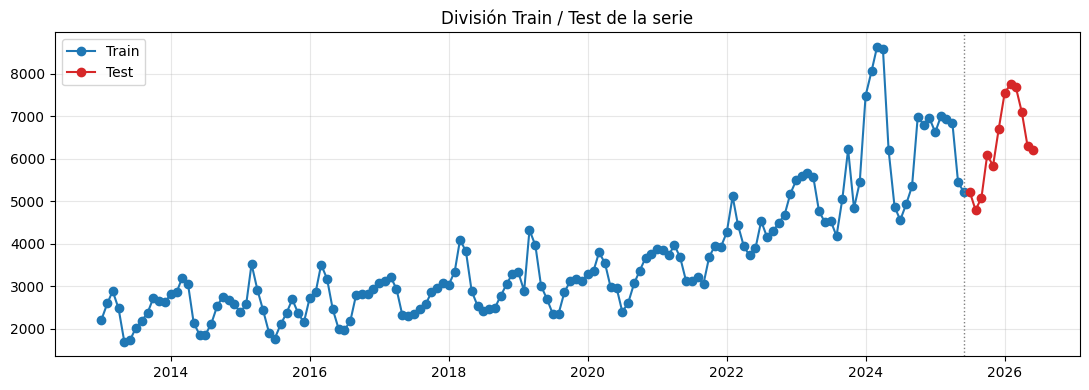

In [61]:
def dividir_train_test(y, test_size=None, m=12, min_train=None):
    """Divide la serie de forma cronologica (sin mezclar el orden temporal).

    - test_size: numero de observaciones para el conjunto de test.
                 Si es None, se calcula automaticamente (hasta m meses).
    - min_train: minimo de observaciones que debe conservar el train
                 (por defecto 3 ciclos estacionales o 24, lo que sea mayor).
    """
    n = len(y)
    min_train = min_train or max(3*m, 24)

    if test_size is None:
        test_size = int(min(m, max(6, n // 5), max(3, n - min_train)))
    test_size = max(1, min(test_size, n - min_train)) if n > min_train else max(1, n // 5)

    y_train = y.iloc[:-test_size]
    y_test  = y.iloc[-test_size:]

    print(f'Serie total   : {n} observaciones')
    print(f'Train         : {len(y_train)} observaciones '
          f'({y_train.index[0].strftime("%Y-%m")} a {y_train.index[-1].strftime("%Y-%m")})')
    print(f'Test          : {len(y_test)} observaciones '
          f'({y_test.index[0].strftime("%Y-%m")} a {y_test.index[-1].strftime("%Y-%m")})')
    return y_train, y_test

y_train, y_test = dividir_train_test(y, test_size=TEST_SIZE, m=M)

plt.figure(figsize=(11, 4))
plt.plot(y_train.index, y_train.values, 'o-', label='Train', color='#1f77b4')
plt.plot(y_test.index, y_test.values, 'o-', label='Test', color='#d62728')
plt.axvline(y_train.index[-1], color='gray', ls=':', lw=1)
plt.title('División Train / Test de la serie')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Fase 4 — Verificación del tamaño y la estacionalidad (train)

In [62]:
def fuerza_estacional(y, m=12):
    """Fs = max(0, 1 - Var(resid)/Var(resid+seasonal)) (Hyndman). >0.3 ~ estacionalidad util."""
    if len(y) < 2*m + 1:
        return np.nan
    try:
        res = STL(y, period=m, robust=True).fit()
    except Exception:
        return np.nan
    var_r  = np.nanvar(res.resid)
    var_rs = np.nanvar(res.resid + res.seasonal)
    return float(max(0.0, 1 - var_r/var_rs)) if var_rs > 0 else 0.0


def verificar_registros(y, m=12):
    n = int(y.dropna().shape[0])
    ciclos = n / m
    nivel = ('INSUFICIENTE' if n < 24 else 'MINIMO' if n < 36 else
             'ACEPTABLE' if n < 48 else 'BUENO' if n < 72 else 'OPTIMO')

    Fs = fuerza_estacional(y, m)
    ciclos_ok = n >= 3*m
    seasonal_ok = bool(ciclos_ok and np.isfinite(Fs) and Fs >= 0.30)
    seasonal_debil = bool(ciclos_ok and np.isfinite(Fs) and 0.15 <= Fs < 0.30)

    presupuesto = max(2, n // 10)          # ~1 parametro por cada 10 observaciones
    max_p = 3 if n >= 60 else 2 if n >= 36 else 1
    max_q = max_p
    max_P = 1 if seasonal_ok else 0
    max_Q = 1 if (seasonal_ok and n >= 4*m) else 0

    info = dict(n=n, ciclos=round(ciclos, 2), nivel=nivel, apto=n >= 24, m=m,
                Fs=None if not np.isfinite(Fs) else round(Fs, 3),
                seasonal_ok=seasonal_ok, seasonal_debil=seasonal_debil,
                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                presupuesto=presupuesto)

    print(f"Registros            : {n}")
    print(f"Ciclos (m={m})        : {ciclos:.2f}")
    print(f"Nivel                : {nivel}")
    print(f"Fuerza estacional Fs : {info['Fs']}  (>=0.30 usa SARIMA, <0.15 no aporta)")
    print(f"Componente estacional: {'SI' if seasonal_ok else 'NO -> ARIMA no estacional'}"
          + (' [debil]' if seasonal_debil else ''))
    print(f"Limites busqueda     : p<={max_p} q<={max_q} P<={max_P} Q<={max_Q} (max {presupuesto} params)")
    if not info['apto']:
        print('ATENCION: serie de train insuficiente para modelar (<24).')
    return info

info = verificar_registros(y_train, m=M)

Registros            : 150
Ciclos (m=12)        : 12.50
Nivel                : OPTIMO
Fuerza estacional Fs : 0.621  (>=0.30 usa SARIMA, <0.15 no aporta)
Componente estacional: SI
Limites busqueda     : p<=3 q<=3 P<=1 Q<=1 (max 15 params)


## Fase 5 — EDA y detección de valores atípicos (train)

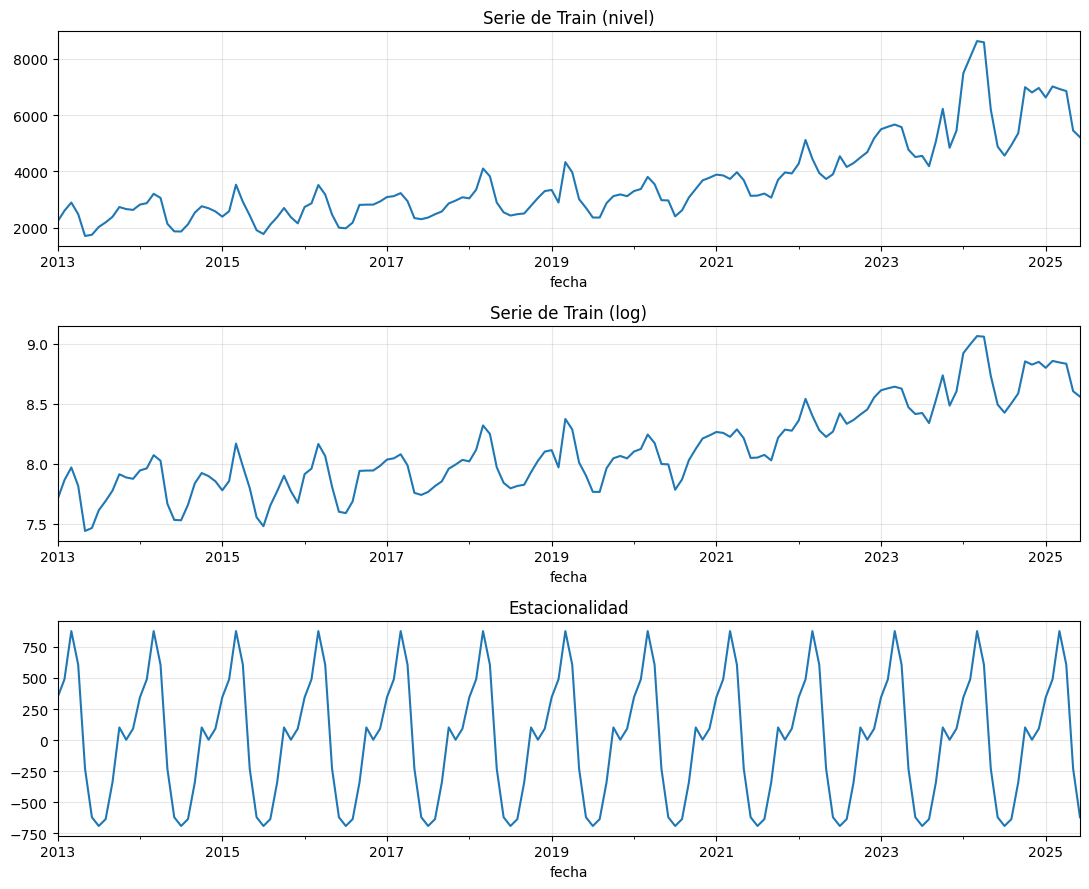

Amplitud estacional = 1,567.3 (43.4% del nivel medio)


In [63]:
fig, ax = plt.subplots(3, 1, figsize=(11, 9))
y_train.plot(ax=ax[0], title='Serie de Train (nivel)'); ax[0].grid(alpha=.3)
np.log(y_train).plot(ax=ax[1], title='Serie de Train (log)'); ax[1].grid(alpha=.3)
if len(y_train) >= 2*M:
    seasonal_decompose(y_train, model='additive', period=M).seasonal.plot(ax=ax[2], title='Estacionalidad')
    ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

if len(y_train) >= 2*M:
    est = seasonal_decompose(y_train, model='additive', period=M).seasonal
    print(f'Amplitud estacional = {est.max()-est.min():,.1f} '
          f'({(est.max()-est.min())/y_train.mean()*100:.1f}% del nivel medio)')

In [64]:
def detectar_outliers(y_serie, umbral=3.5):
    """Detecta variaciones mes a mes atipicas usando un z-score robusto
    (mediana + MAD) sobre las diferencias de primer orden."""
    diffs = y_serie.diff().dropna()
    mediana = diffs.median()
    mad = (diffs - mediana).abs().median()
    if mad == 0:
        return pd.Series(dtype=float)
    z = 0.6745 * (diffs - mediana) / mad
    return diffs[z.abs() > umbral]

atipicos_train = detectar_outliers(y_train)
if len(atipicos_train):
    print(f'Meses con variacion atipica en TRAIN (posibles choques puntuales):')
    for fecha, delta in atipicos_train.items():
        print(f'  {fecha.strftime("%Y-%m")}: variacion = {delta:+,.1f}')
else:
    print('No se detectaron variaciones atipicas relevantes en train.')

atipicos_test = detectar_outliers(pd.concat([y_train.tail(M), y_test]))
atipicos_test = atipicos_test[atipicos_test.index.isin(y_test.index)]
if len(atipicos_test):
    print(f'\nAVISO: el conjunto de TEST tiene meses con variacion atipica; es esperable que el error del modelo suba ahi:')
    for fecha, delta in atipicos_test.items():
        print(f'  {fecha.strftime("%Y-%m")}: variacion = {delta:+,.1f}')

Meses con variacion atipica en TRAIN (posibles choques puntuales):
  2019-03: variacion = +1,435.6
  2023-11: variacion = -1,385.5
  2024-01: variacion = +2,041.0
  2024-05: variacion = -2,389.3
  2024-06: variacion = -1,317.7
  2024-10: variacion = +1,637.6
  2025-05: variacion = -1,403.7


## Fase 6 — Estacionariedad y diferenciación (train)

In [68]:
def test_estacionariedad(x, nombre=''):
    x = pd.Series(x).dropna()
    if len(x) < 8:
        print(f'{nombre}: muestra insuficiente ({len(x)})'); return None, None
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', InterpolationWarning)
        adf = adfuller(x)[1]
        kps = kpss(x, nlags='auto')[1]
    print(f'{nombre}: ADF p={adf:.3f}  KPSS p={kps:.3f}')
    return adf, kps

y_mod_train = np.log(y_train) if USE_LOG else y_train.copy()

test_estacionariedad(y_mod_train, 'nivel (train)')
test_estacionariedad(y_mod_train.diff(), 'd=1 (train)')

def estimar_dD(ys, info, m=12):
    """d y D se ESTIMAN sobre el train, no se imponen. D solo si hay senal estacional real."""
    if HAS_PMDARIMA:
        d = int(min(2, ndiffs(ys, test='kpss', max_d=2)))
    else:
        d = 0 if test_estacionariedad(ys, '_')[0] < 0.05 else 1
    D = 0
    if info['seasonal_ok'] and len(ys) >= 3*m + m:
        if HAS_PMDARIMA:
            try:
                D = int(min(1, nsdiffs(ys, m=m, max_D=1, test='ocsb')))
            except Exception:
                D = 0
        else:
            D = 1
        if len(ys) - D*m - d < 2*m:   # nunca dejar menos de 2 ciclos utiles
            D = 0
    print(f'Diferenciacion estimada (train) -> d={d}, D={D} (m={m})')
    return d, D

D_ORDER, D_SEAS = estimar_dD(y_mod_train, info, M)

nivel (train): ADF p=0.997  KPSS p=0.010
d=1 (train): ADF p=0.000  KPSS p=0.100
Diferenciacion estimada (train) -> d=1, D=0 (m=12)


## Fase 7 — Identificación (ACF/PACF, train)

n efectivo tras diferenciar (train) = 149 | lags = 36


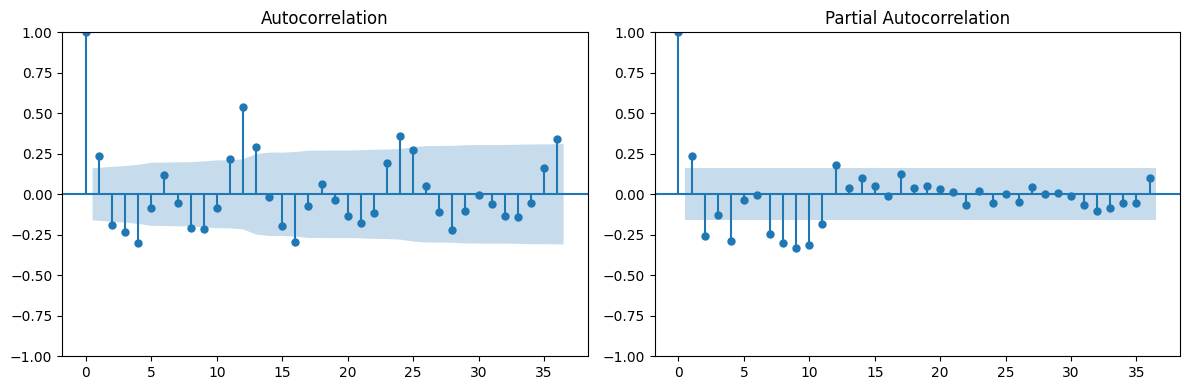

ACF(lag 12) = 0.586


In [69]:
yd = y_mod_train.copy()
for _ in range(D_ORDER): yd = yd.diff()
for _ in range(D_SEAS):  yd = yd.diff(M)
yd = yd.dropna()

n = len(yd)
lags = max(4, min(36, (n // 2) - 1))
print(f'n efectivo tras diferenciar (train) = {n} | lags = {lags}')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(yd, lags=lags, ax=ax[0]); plot_pacf(yd, lags=lags, method='ywm', ax=ax[1])
plt.tight_layout(); plt.show()

if len(yd) > M:
    acf_m = pd.Series(yd).autocorr(lag=M)
    print(f'ACF(lag {M}) = {acf_m:.3f}' +
          ('  <-- posible SOBRE-diferenciacion estacional (revisa D)' if acf_m < -0.35 else ''))

## Fase 8 — Estimación del modelo (auto_arima / grid AIC) — ajustada SOLO sobre train

In [70]:
FIT_KW = dict(enforce_stationarity=True, enforce_invertibility=True)

def _fit(ys, order, sorder, trend=None):
    return SARIMAX(ys, order=order, seasonal_order=sorder, trend=trend, **FIT_KW).fit(disp=False)

def modelo_estable(fit):
    """True si todas las raices AR (y estacionales) estan fuera del circulo unitario."""
    try:
        ar = np.concatenate([np.atleast_1d(fit.arroots), np.atleast_1d(getattr(fit, 'seasonalarroots', []))])
        return bool(len(ar) == 0 or np.all(np.abs(ar) > 1.01))
    except Exception:
        return True

def ajustar_sarima(ys, info, d, D, m=12, verbose=True):
    """ys ya viene en la escala de modelado (log si USE_LOG). Se ajusta SOLO con datos de train."""
    seasonal = info['seasonal_ok'] and (D > 0 or info['max_P'] + info['max_Q'] > 0)
    max_p, max_q = info['max_p'], info['max_q']
    max_P = info['max_P'] if seasonal else 0
    max_Q = info['max_Q'] if seasonal else 0

    order, sorder = (1, d, 0), ((1, D, 0, m) if seasonal else (0, 0, 0, 0))
    if HAS_PMDARIMA:
        try:
            mdl = pm.auto_arima(ys, seasonal=seasonal, m=m if seasonal else 1,
                                d=d, D=D if seasonal else 0,
                                start_p=0, start_q=0, start_P=0, start_Q=0,
                                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                                information_criterion='aicc',
                                stationary=False, stepwise=True,
                                suppress_warnings=True, error_action='ignore', trace=False)
            order, sorder = mdl.order, (mdl.seasonal_order if seasonal else (0, 0, 0, 0))
        except Exception as e:
            if verbose: print('auto_arima fallo, uso fallback:', e)
    else:
        mejor, best = None, np.inf
        for p in range(max_p+1):
            for q in range(max_q+1):
                for P in range(max_P+1):
                    for Q in range(max_Q+1):
                        try:
                            f = _fit(ys, (p, d, q), (P, D, Q, m) if seasonal else (0, 0, 0, 0))
                            if f.aicc < best and modelo_estable(f):
                                best, mejor = f.aicc, ((p, d, q), (P, D, Q, m) if seasonal else (0, 0, 0, 0))
                        except Exception:
                            continue
        if mejor: order, sorder = mejor

    k = order[0] + order[2] + sorder[0] + sorder[2]
    if k > info['presupuesto']:
        if verbose: print(f'Modelo simplificado: k={k} > presupuesto={info["presupuesto"]}')
        order  = (1, d, 0)
        sorder = (1, D, 0, m) if seasonal else (0, 0, 0, 0)

    try:
        if not modelo_estable(_fit(ys, order, sorder)):
            if verbose: print('Modelo inestable -> degradado a (0,d,1)')
            order  = (0, d, 1)
            sorder = (0, D, 1, m) if seasonal else (0, 0, 0, 0)
    except Exception:
        order, sorder = (0, d, 1), (0, 0, 0, 0)
    return order, sorder

order, seasonal_order = ajustar_sarima(y_mod_train, info, D_ORDER, D_SEAS, M)
print('order =', order, '| seasonal_order =', seasonal_order, '| use_log =', USE_LOG)

Modelo inestable -> degradado a (0,d,1)
order = (0, 1, 1) | seasonal_order = (0, 0, 1, 12) | use_log = True


## Fase 9 — Diagnóstico de residuos (ajuste sobre train)

                                     SARIMAX Results                                      
Dep. Variable:                             precio   No. Observations:                  150
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 12)   Log Likelihood                 110.535
Date:                            Fri, 07 Aug 2026   AIC                           -215.070
Time:                                    18:10:11   BIC                           -206.059
Sample:                                01-01-2013   HQIC                          -211.409
                                     - 06-01-2025                                         
Covariance Type:                              opg                                         
Modelo estable (raices AR fuera del circulo): True
residuos utiles = 149 | lags diagnostico = 24


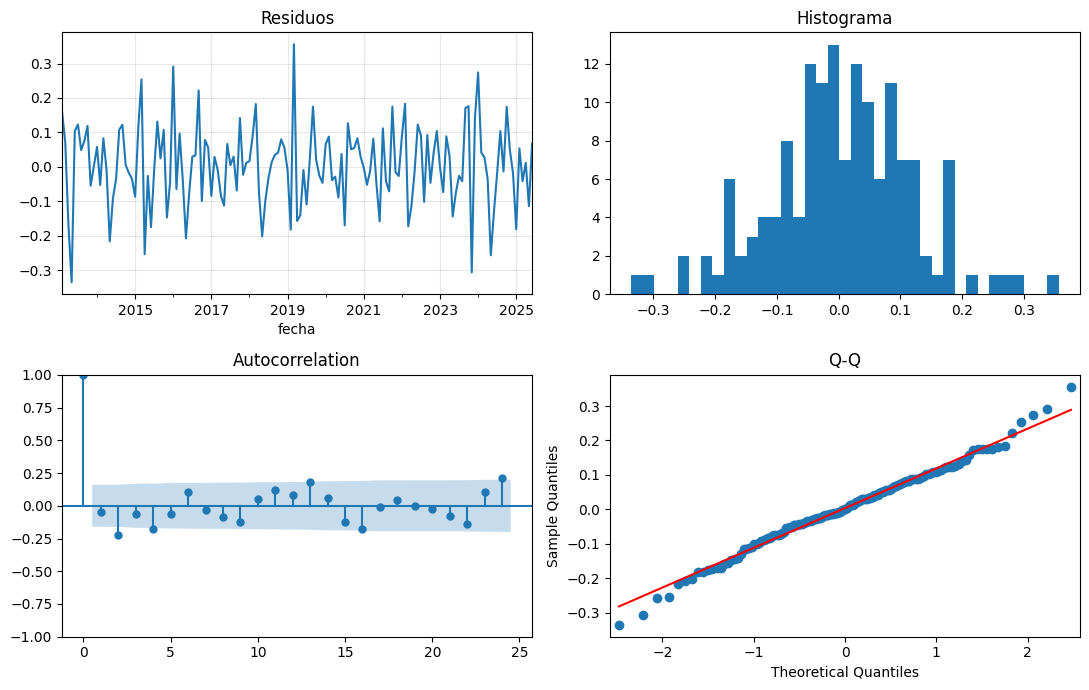

      lb_stat  lb_pvalue
10  19.996252   0.029288
Ruido blanco (p>0.05): False
Jarque-Bera p = 0.4007


In [71]:
fit_train = _fit(y_mod_train, order, seasonal_order)
print(fit_train.summary().tables[0])
print('Modelo estable (raices AR fuera del circulo):', modelo_estable(fit_train))

resid = pd.Series(fit_train.resid).replace([np.inf, -np.inf], np.nan).dropna()
burn = order[1] + seasonal_order[1]*(seasonal_order[3] or 0)
resid = resid.iloc[burn:]
nr = len(resid)
lags_r = max(2, min(24, (nr // 2) - 1))
print(f'residuos utiles = {nr} | lags diagnostico = {lags_r}')

if nr >= 8:
    fig, ax = plt.subplots(2, 2, figsize=(11, 7))
    resid.plot(ax=ax[0,0], title='Residuos'); ax[0,0].grid(alpha=.3)
    ax[0,1].hist(resid, bins=max(5, nr//4)); ax[0,1].set_title('Histograma')
    plot_acf(resid, lags=lags_r, ax=ax[1,0])
    qqplot(resid, line='s', ax=ax[1,1]); ax[1,1].set_title('Q-Q')
    plt.tight_layout(); plt.show()
    lb = acorr_ljungbox(resid, lags=[max(1, min(lags_r, 10))], return_df=True)
    print(lb)
    print('Ruido blanco (p>0.05):', bool(lb['lb_pvalue'].iloc[0] > 0.05))
    print('Jarque-Bera p =', round(stats.jarque_bera(resid)[1], 4))
else:
    print('Muy pocos residuos para diagnostico grafico.')

## Fase 10 — Evaluación en Test (walk-forward, 1 paso adelante) + métrica de Accuracy

In [72]:
def _metricas(y_true, y_pred, y_train_orig, m=12):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    mae   = np.mean(np.abs(y_true - y_pred))
    rmse  = np.sqrt(np.mean((y_true - y_pred)**2))
    mape  = np.mean(np.abs((y_true - y_pred)/y_true)) * 100
    smape = np.mean(2*np.abs(y_true - y_pred)/(np.abs(y_true) + np.abs(y_pred))) * 100
    yt = np.asarray(y_train_orig, float)
    lag = m if len(yt) > m + 2 else 1
    denom = np.mean(np.abs(yt[lag:] - yt[:-lag])) if len(yt) > lag else np.nan
    mase = mae/denom if denom and denom > 0 else np.nan
    accuracy = max(0.0, 100 - mape)
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, sMAPE=smape, MASE=mase, Accuracy=accuracy)


def backtest_walkforward(y, n_train, order, sorder, use_log, trend=None):
    """Validacion walk-forward de 1 paso adelante sobre el test.

    En cada paso i se reestima el modelo (mismo order/sorder/trend) usando
    los datos hasta n_train+i, y se pronostica un unico paso adelante.
    """
    n_test = len(y) - n_train
    preds = []
    for i in range(n_test):
        y_hist = y.iloc[: n_train + i]
        ym = np.log(y_hist) if use_log else y_hist
        try:
            f = SARIMAX(ym, order=order, seasonal_order=sorder, trend=trend, **FIT_KW).fit(disp=False)
            mu = float(f.get_forecast(steps=1).predicted_mean.iloc[0])
            p = float(np.exp(mu)) if use_log else mu
            if not np.isfinite(p):
                raise ValueError('pronostico no finito')
        except Exception:
            p = float(y_hist.iloc[-1])   # fallback: ultimo valor conocido
        preds.append(p)
    return np.array(preds)


H_TEST = len(y_test)
n_train = len(y_train)
order_ns = (order[0], order[1], order[2])
usa_estacional = bool(seasonal_order[3]) and (seasonal_order[0] or seasonal_order[1] or seasonal_order[2])

resultados, curvas_test = {}, {}

pred_sarima = backtest_walkforward(y, n_train, order, seasonal_order, USE_LOG)
resultados['SARIMA'] = _metricas(y_test.values, pred_sarima, y_train.values, m=M)
curvas_test['SARIMA'] = pred_sarima

if usa_estacional:
    pred_arima = backtest_walkforward(y, n_train, order_ns, (0,0,0,0), USE_LOG)
    resultados['ARIMA (sin estacional)'] = _metricas(y_test.values, pred_arima, y_train.values, m=M)
    curvas_test['ARIMA (sin estacional)'] = pred_arima

pred_simple = backtest_walkforward(y, n_train, (0,1,1), (0,0,0,0), USE_LOG)
resultados['ARIMA(0,1,1)'] = _metricas(y_test.values, pred_simple, y_train.values, m=M)
curvas_test['ARIMA(0,1,1)'] = pred_simple

try:
    pred_drift = backtest_walkforward(y, n_train, order, seasonal_order, USE_LOG, trend='t')
    resultados['SARIMA con tendencia'] = _metricas(y_test.values, pred_drift, y_train.values, m=M)
    curvas_test['SARIMA con tendencia'] = pred_drift
except Exception as e:
    print('No fue posible ajustar la variante con tendencia (drift):', e)

comparativa = pd.DataFrame(resultados).T[['MAE','RMSE','MAPE','sMAPE','MASE','Accuracy']]
comparativa = comparativa.sort_values('MASE')
print(f'=== COMPARATIVA DE VARIANTES SARIMA/ARIMA EN TEST — walk-forward 1 paso (h={H_TEST} meses) ===')
print(comparativa.round(3).to_string())

=== COMPARATIVA DE VARIANTES SARIMA/ARIMA EN TEST — walk-forward 1 paso (h=12 meses) ===
                            MAE     RMSE   MAPE  sMAPE   MASE  Accuracy
ARIMA (sin estacional)  436.044  534.634  7.050  7.165  0.883    92.950
ARIMA(0,1,1)            436.044  534.634  7.050  7.165  0.883    92.950
SARIMA                  468.732  582.213  7.494  7.592  0.950    92.506
SARIMA con tendencia    480.974  589.531  7.688  7.752  0.974    92.312


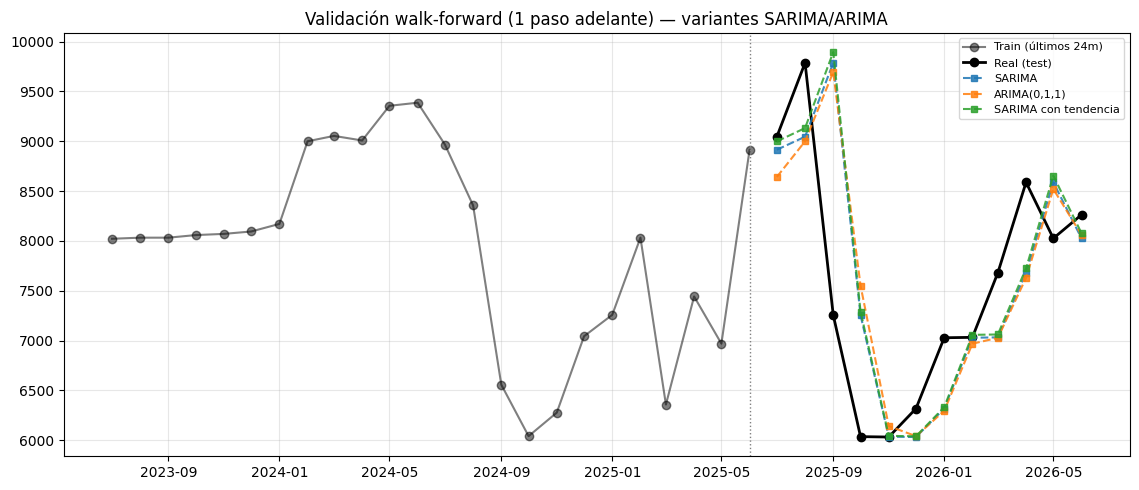

In [39]:
plt.figure(figsize=(11.5, 5))
plt.plot(y_train.index[-24:], y_train.values[-24:], 'ko-', lw=1.5, alpha=.5, label='Train (últimos 24m)')
plt.plot(y_test.index, y_test.values, 'ko-', lw=2, label='Real (test)')
for nom, pred in curvas_test.items():
    plt.plot(y_test.index, pred, '--', marker='s', ms=4, alpha=.85, label=nom)
plt.axvline(y_train.index[-1], color='gray', ls=':', lw=1)
plt.title('Validación walk-forward (1 paso adelante) — variantes SARIMA/ARIMA')
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Fase 11 — Selección de la variante ganadora


In [73]:
crit = 'MASE' if comparativa['MASE'].notna().all() else 'MAE'
GANADOR = comparativa[crit].idxmin()
mase_g = float(comparativa.loc[GANADOR, 'MASE'])
acc_g  = float(comparativa.loc[GANADOR, 'Accuracy'])

print('='*64)
print(f'MEJOR VARIANTE: {GANADOR}   ({crit} = {comparativa.loc[GANADOR, crit]:.3f}  |  Accuracy = {acc_g:.1f}%)')
print('='*64)

if np.isfinite(mase_g):
    if mase_g < 0.8:   veredicto = 'Aporta valor claro sobre el naive estacional (regla practica MASE<1).'
    elif mase_g < 1.0: veredicto = 'Mejora marginal sobre el naive; util pero con poco margen.'
    else:              veredicto = 'El modelo NO supera al naive estacional: revisar especificacion.'
    print(f'MASE={mase_g:.3f} -> {veredicto}')

if len(comparativa) > 1:
    segundo = comparativa.index[1]
    print(f'Segundo lugar: {segundo} ({crit}={comparativa.loc[segundo, crit]:.3f}, '
          f'Accuracy={comparativa.loc[segundo, "Accuracy"]:.1f}%)')

MEJOR VARIANTE: ARIMA (sin estacional)   (MASE = 0.883  |  Accuracy = 92.9%)
MASE=0.883 -> Mejora marginal sobre el naive; util pero con poco margen.
Segundo lugar: ARIMA(0,1,1) (MASE=0.883, Accuracy=92.9%)


## Fase 12 — Reentrenamiento con la serie completa

In [75]:
y_mod_full = np.log(y) if USE_LOG else y.copy()

TREND_FINAL = None
if GANADOR == 'SARIMA':
    order_final, sorder_final = order, seasonal_order
elif GANADOR == 'ARIMA (sin estacional)':
    order_final, sorder_final = order_ns, (0,0,0,0)
elif GANADOR == 'ARIMA(0,1,1)':
    order_final, sorder_final = (0,1,1), (0,0,0,0)
elif GANADOR == 'SARIMA con tendencia':
    order_final, sorder_final = order, seasonal_order
    TREND_FINAL = 't'
else:
    order_final, sorder_final = order, seasonal_order

fit_full = SARIMAX(y_mod_full, order=order_final, seasonal_order=sorder_final,
                    trend=TREND_FINAL, **FIT_KW).fit(disp=False)

if not modelo_estable(fit_full):
    print('AVISO: modelo inestable al reentrenar con la serie completa, degradando a (0,1,1)')
    order_final, sorder_final, TREND_FINAL = (0,1,1), (0,0,0,0), None
    fit_full = SARIMAX(y_mod_full, order=order_final, seasonal_order=sorder_final,
                        trend=TREND_FINAL, **FIT_KW).fit(disp=False)

print(f'Reentrenado {GANADOR} con la serie completa: order={order_final}, '
      f'seasonal_order={sorder_final}, trend={TREND_FINAL}')

Reentrenado ARIMA (sin estacional) con la serie completa: order=(0, 1, 1), seasonal_order=(0, 0, 0, 0), trend=None


#Fase 13: Pronostico a realizar

In [76]:
fut_idx = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=H_FUTURO, freq='MS')

fc = fit_full.get_forecast(steps=H_FUTURO)
mu = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)
if USE_LOG:
    punto = np.exp(mu).values
    lo, hi = np.exp(ci.iloc[:,0]).values, np.exp(ci.iloc[:,1]).values
else:
    punto = mu.values; lo, hi = ci.iloc[:,0].values, ci.iloc[:,1].values

lo_h, hi_h = y.min()*0.4, y.max()*2.5
forecast_final = pd.DataFrame({'pred': punto, 'lo95': lo, 'hi95': hi}, index=fut_idx)
forecast_final['var_%_vs_mes_previo'] = forecast_final['pred'].pct_change().fillna(
    forecast_final['pred'].iloc[0]/float(y.iloc[-1]) - 1) * 100
forecast_final.index.name = 'Mes'

fuera_rango = forecast_final[(forecast_final['pred'] < lo_h) | (forecast_final['pred'] > hi_h)]
print(f'PRONOSTICO {H_FUTURO} MESES  |  modelo: {GANADOR}')
print(forecast_final.round(2).to_string())
print('\nFuera de rango plausible:', 'ninguno OK' if fuera_rango.empty else fuera_rango.index.strftime('%Y-%m').tolist())

PRONOSTICO 12 MESES  |  modelo: ARIMA (sin estacional)
               pred     lo95      hi95  var_%_vs_mes_previo
Mes                                                        
2026-07-01  6255.09  4890.94   7999.72                 0.64
2026-08-01  6255.09  4131.07   9471.20                 0.00
2026-09-01  6255.09  3672.11  10654.97                 0.00
2026-10-01  6255.09  3335.70  11729.54                 0.00
2026-11-01  6255.09  3069.30  12747.60                 0.00
2026-12-01  6255.09  2849.02  13733.19                 0.00
2027-01-01  6255.09  2661.71  14699.61                 0.00
2027-02-01  6255.09  2499.25  15655.14                 0.00
2027-03-01  6255.09  2356.24  16605.33                 0.00
2027-04-01  6255.09  2228.89  17554.12                 0.00
2027-05-01  6255.09  2114.42  18504.45                 0.00
2027-06-01  6255.09  2010.74  19458.55                 0.00

Fuera de rango plausible: ninguno OK


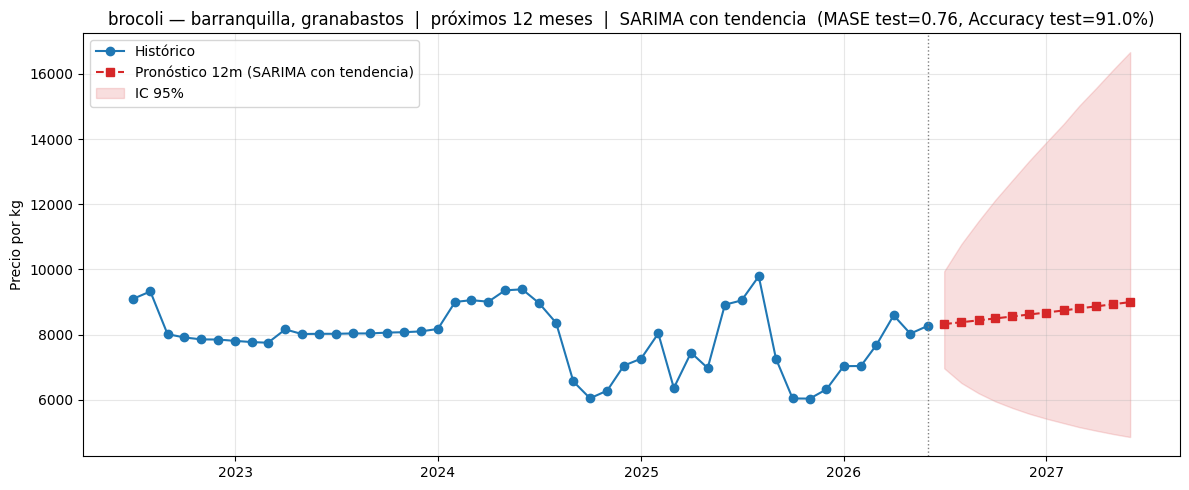

guardado: pronostico_final.csv


In [43]:
plt.figure(figsize=(12, 5))
hist_plot = y.iloc[-min(len(y), 48):]
plt.plot(hist_plot.index, hist_plot.values, 'o-', color='#1f77b4', label='Histórico')
plt.plot(forecast_final.index, forecast_final['pred'], 's--', color='#d62728',
         label=f'Pronóstico {H_FUTURO}m ({GANADOR})')
plt.fill_between(forecast_final.index, forecast_final['lo95'], forecast_final['hi95'],
                 color='#d62728', alpha=.15, label='IC 95%')
plt.axvline(y.index[-1], color='gray', ls=':', lw=1)
plt.title(f'{producto} — {mercado}  |  próximos {H_FUTURO} meses  |  {GANADOR}  '
          f'(MASE test={mase_g:.2f}, Accuracy test={acc_g:.1f}%)')
plt.ylabel('Precio por kg'); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

forecast_final.round(2).to_csv('pronostico_final.csv')
print('guardado: pronostico_final.csv')

## Fase 14 — Persistencia del modelo

In [77]:
joblib.dump({
    'ganador': GANADOR,
    'fit_full': fit_full,
    'order': order_final,
    'seasonal_order': sorder_final,
    'trend': TREND_FINAL,
    'use_log': USE_LOG,
    'm': M,
    'info': info,
    'metricas_test': comparativa.loc[GANADOR].to_dict(),
    'producto': producto,
    'mercado': mercado,
}, 'modelo_final.pkl')
print('modelo guardado en modelo_final.pkl')

modelo guardado en modelo_final.pkl


##Fase 15 - Resultados finales y resumen de proceso

In [78]:
print('='*70)
print('RESUMEN DE RESULTADOS')
print('='*70)
print(f'Serie                  : {producto} en {mercado_label}  (n={len(y)} meses, {len(y)/M:.1f} ciclos)')
print(f'Train / Test           : {len(y_train)} / {len(y_test)} meses')
print(f'Estacionalidad         : Fs={info["Fs"]} -> ' + ('usada' if info['seasonal_ok'] else 'NO usada (senal debil)'))
print(f'Modelo Fase 7 (train)  : SARIMA{order}x{seasonal_order}')
print('-'*70)
print('Metricas en TEST (walk-forward, variantes SARIMA/ARIMA):')
print(comparativa.round(3).to_string())
print('-'*70)
print(f'MEJOR VARIANTE          : {GANADOR}   (MASE={mase_g:.3f}, Accuracy={acc_g:.1f}%, '
      f'MAE={comparativa.loc[GANADOR,"MAE"]:,.1f}, sMAPE={comparativa.loc[GANADOR,"sMAPE"]:.1f}%)')
print(f'Ultimo observado {y.index[-1].strftime("%Y-%m")} : {y.iloc[-1]:,.2f}')
print(f'Pronostico {forecast_final.index[0].strftime("%Y-%m")}       : {forecast_final["pred"].iloc[0]:,.2f} '
      f'[{forecast_final["lo95"].iloc[0]:,.2f} ; {forecast_final["hi95"].iloc[0]:,.2f}]')
print(f'Pronostico a {H_FUTURO} meses ({forecast_final.index[-1].strftime("%Y-%m")}) : {forecast_final["pred"].iloc[-1]:,.2f}')
print('='*70)

# --- Tabla de pronostico de los proximos meses ---
tabla_pronostico = forecast_final.copy()
tabla_pronostico.index = tabla_pronostico.index.strftime('%Y-%m')
tabla_pronostico.index.name = 'Mes'
tabla_pronostico = tabla_pronostico.rename(columns={
    'pred': 'Pronóstico',
    'lo95': 'Límite inferior 95%',
    'hi95': 'Límite superior 95%',
    'var_%_vs_mes_previo': 'Variación % vs mes previo',
}).round(2)

print(f'\nTABLA DE PRONÓSTICO — próximos {H_FUTURO} meses ({producto}, {mercado_label})')
display(tabla_pronostico)

RESUMEN DE RESULTADOS
Serie                  : aguacate comun en Colombia (promedio nacional)  (n=162 meses, 13.5 ciclos)
Train / Test           : 150 / 12 meses
Estacionalidad         : Fs=0.621 -> usada
Modelo Fase 7 (train)  : SARIMA(0, 1, 1)x(0, 0, 1, 12)
----------------------------------------------------------------------
Metricas en TEST (walk-forward, variantes SARIMA/ARIMA):
                            MAE     RMSE   MAPE  sMAPE   MASE  Accuracy
ARIMA (sin estacional)  436.044  534.634  7.050  7.165  0.883    92.950
ARIMA(0,1,1)            436.044  534.634  7.050  7.165  0.883    92.950
SARIMA                  468.732  582.213  7.494  7.592  0.950    92.506
SARIMA con tendencia    480.974  589.531  7.688  7.752  0.974    92.312
----------------------------------------------------------------------
MEJOR VARIANTE          : ARIMA (sin estacional)   (MASE=0.883, Accuracy=92.9%, MAE=436.0, sMAPE=7.2%)
Ultimo observado 2026-06 : 6,215.50
Pronostico 2026-07       : 6,255.09 [4,890

,Pronóstico,Límite inferior 95%,Límite superior 95%,Variación % vs mes previo
Mes,,,,
2026-07,6255.09,4890.94,7999.72,0.64
2026-08,6255.09,4131.07,9471.20,0.00
2026-09,6255.09,3672.11,10654.97,0.00
2026-10,6255.09,3335.70,11729.54,0.00
2026-11,6255.09,3069.30,12747.60,0.00
2026-12,6255.09,2849.02,13733.19,0.00
2027-01,6255.09,2661.71,14699.61,0.00
2027-02,6255.09,2499.25,15655.14,0.00
2027-03,6255.09,2356.24,16605.33,0.00


**Último paso**: Guardar el Modelo para ser utilizado en el **Producto de Datos**

**Producto de Datos**:

- Aplicación Web, formulario que pide los datos y entrega la estimación/predicción/etc.
- Aplicación Móvil
- Tablero o _Dashboard_: Dash, Streamlit, Flask, PowerBI, Tableau, Qlik, Looker
- API: permite hacer las consultas para "embeberlas" en una aplicación de usuario
